In [12]:
from google.colab import drive
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
import math
import tensorflow as tf

drive.mount('/content/drive')

REPO_PATH = "/content/drive/MyDrive/BraTS_Project/brats-brain-tumor"
SRC_PATH = os.path.join(REPO_PATH, "src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

try:
    %load_ext autoreload
    %autoreload 2
except ModuleNotFoundError:
    import importlib

print(f"Project 'src' directory added to sys.path: {SRC_PATH}")
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project 'src' directory added to sys.path: /content/drive/MyDrive/BraTS_Project/brats-brain-tumor/src
Setup complete.


Setup & Data Paths

Setup complete. Training data found: 371 patients.
--- Loaded: BraTS20_Training_001_flair.nii ---
Shape: (240, 240, 155) | Dtype: float64


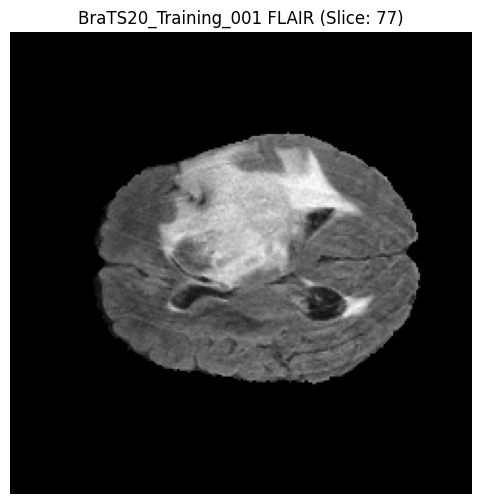

In [13]:
from eda_utils import load_nifti_data, show_nifti_slice

BASE_PATH = "/content/drive/MyDrive/BraTS_Project/data"
TRAIN_DATA_PATH = os.path.join(BASE_PATH,"BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

SAMPLE_PATIENT_ID = "BraTS20_Training_001"
SAMPLE_FILE_NAME = f"{SAMPLE_PATIENT_ID}_flair.nii"
SAMPLE_FILE = os.path.join(TRAIN_DATA_PATH, SAMPLE_PATIENT_ID, SAMPLE_FILE_NAME)

sys.path.append(os.path.join(REPO_PATH, "src"))

print(f"Setup complete. Training data found: {len(os.listdir(TRAIN_DATA_PATH))} patients.")

image_data = load_nifti_data(SAMPLE_FILE)
show_nifti_slice(image_data, title=f"{SAMPLE_PATIENT_ID} FLAIR")

Patient and Modality Analysis

In [14]:
patient_folders = sorted([f for f in os.listdir(TRAIN_DATA_PATH) if f.startswith("BraTS20")])

print(f"Total Patients (Volumes): {len(patient_folders)}")
print(f"Sample Patient IDs: {patient_folders[:5]}")

sample_patient = patient_folders[0]
sample_patient_path = os.path.join(TRAIN_DATA_PATH, sample_patient)
print(f"\nFiles in {sample_patient}:")
for f in os.listdir(sample_patient_path):
    print(f" - {f}")

Total Patients (Volumes): 369
Sample Patient IDs: ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003', 'BraTS20_Training_004', 'BraTS20_Training_005']

Files in BraTS20_Training_001:
 - BraTS20_Training_001_flair.nii
 - BraTS20_Training_001_seg.nii
 - BraTS20_Training_001_t1.nii
 - BraTS20_Training_001_t1ce.nii
 - BraTS20_Training_001_t2.nii


Tumor vs Background Ratio (Volume-based)

--- Loaded: BraTS20_Training_001_seg.nii ---
Shape: (240, 240, 155) | Dtype: float64


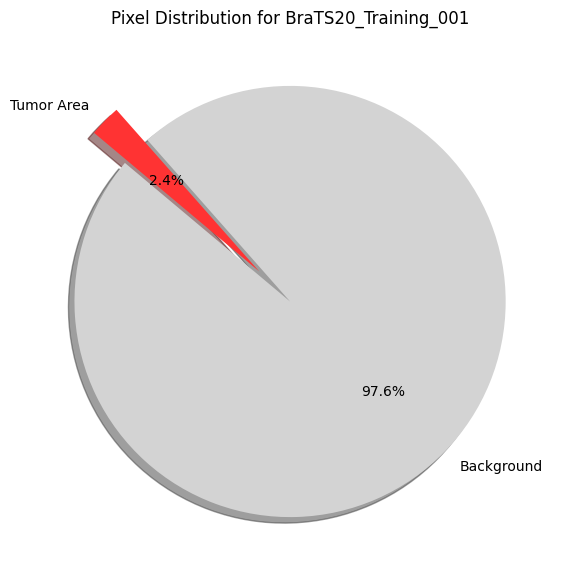

In [15]:
from eda_utils import load_nifti_data

sample_mask_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_seg.nii")
mask_data = load_nifti_data(sample_mask_path)

total_pixels = mask_data.size
tumor_pixels = np.count_nonzero(mask_data)
background_pixels = total_pixels - tumor_pixels

labels = ['Background', 'Tumor Area']
sizes = [background_pixels, tumor_pixels]
colors = ['#d3d3d3', '#ff3333']
explode = (0, 0.2)

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140, colors=colors)
plt.title(f"Pixel Distribution for {sample_patient}")
plt.show()

Multi-Channel MRI Visualization

--- Loaded: BraTS20_Training_001_flair.nii ---
Shape: (240, 240, 155) | Dtype: float64
--- Loaded: BraTS20_Training_001_t1.nii ---
Shape: (240, 240, 155) | Dtype: float64
--- Loaded: BraTS20_Training_001_t1ce.nii ---
Shape: (240, 240, 155) | Dtype: float64
--- Loaded: BraTS20_Training_001_t2.nii ---
Shape: (240, 240, 155) | Dtype: float64


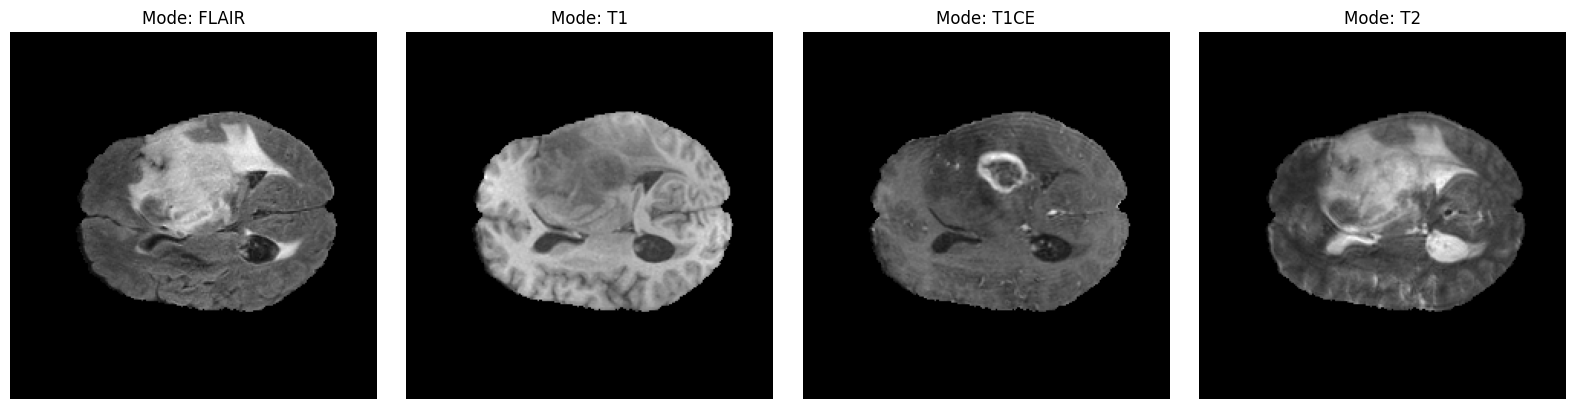

In [16]:
modalities = ['flair', 't1', 't1ce', 't2']
slice_no = 75

plt.figure(figsize=(16, 4))

for i, mod in enumerate(modalities):
    file_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_{mod}.nii")
    data = load_nifti_data(file_path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(data[:, :, slice_no], cmap="gray")
    plt.title(f"Mode: {mod.upper()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Intensity Distribution

--- Loaded: BraTS20_Training_001_flair.nii ---
Shape: (240, 240, 155) | Dtype: float64


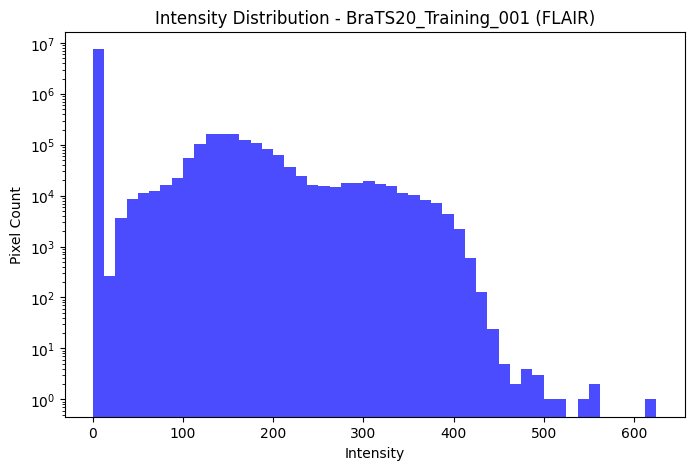

In [17]:
flair_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_flair.nii")
flair_data = load_nifti_data(flair_path)

plt.figure(figsize=(8, 5))
plt.hist(flair_data.flatten(), bins=50, color='blue', alpha=0.7)
plt.title(f"Intensity Distribution - {sample_patient} (FLAIR)")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.yscale('log')
plt.show()

Combined Tumor Regions and Overlay

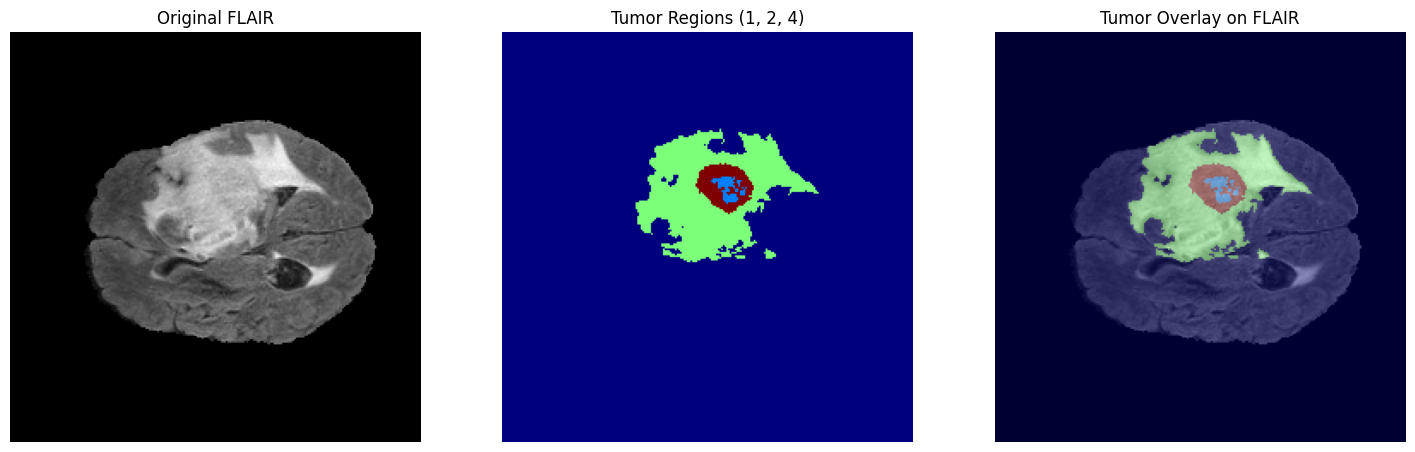

In [18]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(flair_data[:, :, slice_no], cmap="gray")
plt.title("Original FLAIR")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_data[:, :, slice_no], cmap="jet")
plt.title("Tumor Regions (1, 2, 4)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(flair_data[:, :, slice_no], cmap="gray")
plt.imshow(mask_data[:, :, slice_no], cmap="jet", alpha=0.4)
plt.title("Tumor Overlay on FLAIR")
plt.axis("off")

plt.show()

Frequency of Different Tumor Regions (Bar Chart)

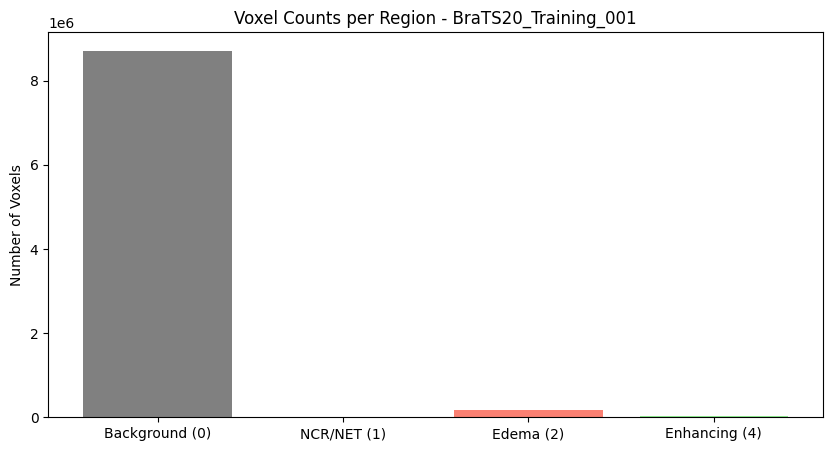

Region Statistics:
Background (0): 8716021 voxels
NCR/NET (1): 15443 voxels
Edema (2): 168794 voxels
Enhancing (4): 27742 voxels


In [19]:
unique_labels = np.unique(mask_data)
region_counts = {
    "Background (0)": np.sum(mask_data == 0),
    "NCR/NET (1)": np.sum(mask_data == 1),
    "Edema (2)": np.sum(mask_data == 2),
    "Enhancing (4)": np.sum(mask_data == 4)
}

plt.figure(figsize=(10, 5))
plt.bar(region_counts.keys(), region_counts.values(), color=['gray', 'skyblue', 'salmon', 'lightgreen'])
plt.title(f"Voxel Counts per Region - {sample_patient}")
plt.ylabel("Number of Voxels")
plt.show()

print("Region Statistics:")
for k, v in region_counts.items():
    print(f"{k}: {v} voxels")

Tumor Slice Analysis Across the Entire Dataset (Ratio Graph)

Scanning dataset... (This might take a few minutes)


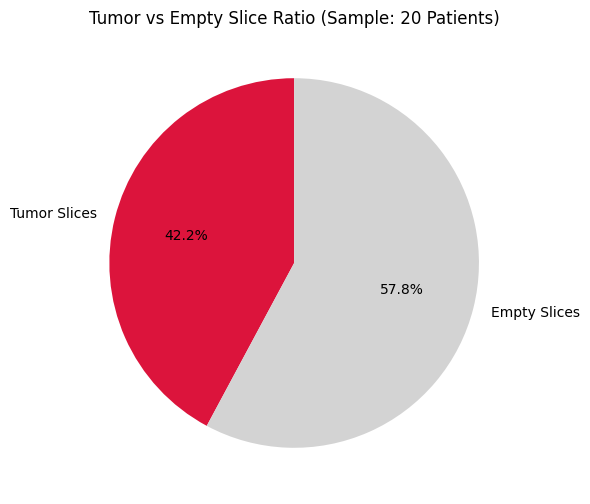

Total slices scanned: 3100
Tumor slices found: 1307


In [21]:
import nibabel as nib

patient_folders = sorted([f for f in os.listdir(TRAIN_DATA_PATH) if f.startswith("BraTS20")])

total_slices = 0
tumor_slices = 0

print("Scanning dataset... (This might take a few minutes)")

sample_size = 20

for patient in patient_folders[:sample_size]:
    mask_path = os.path.join(TRAIN_DATA_PATH, patient, f"{patient}_seg.nii")
    if os.path.exists(mask_path):
        mask_data = nib.load(mask_path).get_fdata()
        total_slices += mask_data.shape[2]

        for i in range(mask_data.shape[2]):
            if np.max(mask_data[:, :, i]) > 0:
                tumor_slices += 1

empty_slices = total_slices - tumor_slices

labels = ["Tumor Slices", "Empty Slices"]
values = [tumor_slices, empty_slices]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90, colors=['crimson', 'lightgray'])
plt.title(f"Tumor vs Empty Slice Ratio (Sample: {sample_size} Patients)")
plt.show()

print(f"Total slices scanned: {total_slices}")
print(f"Tumor slices found: {tumor_slices}")

Identification of the Initial Tumorous Slice and Channels

Top tumor intensity found in Slice: 67


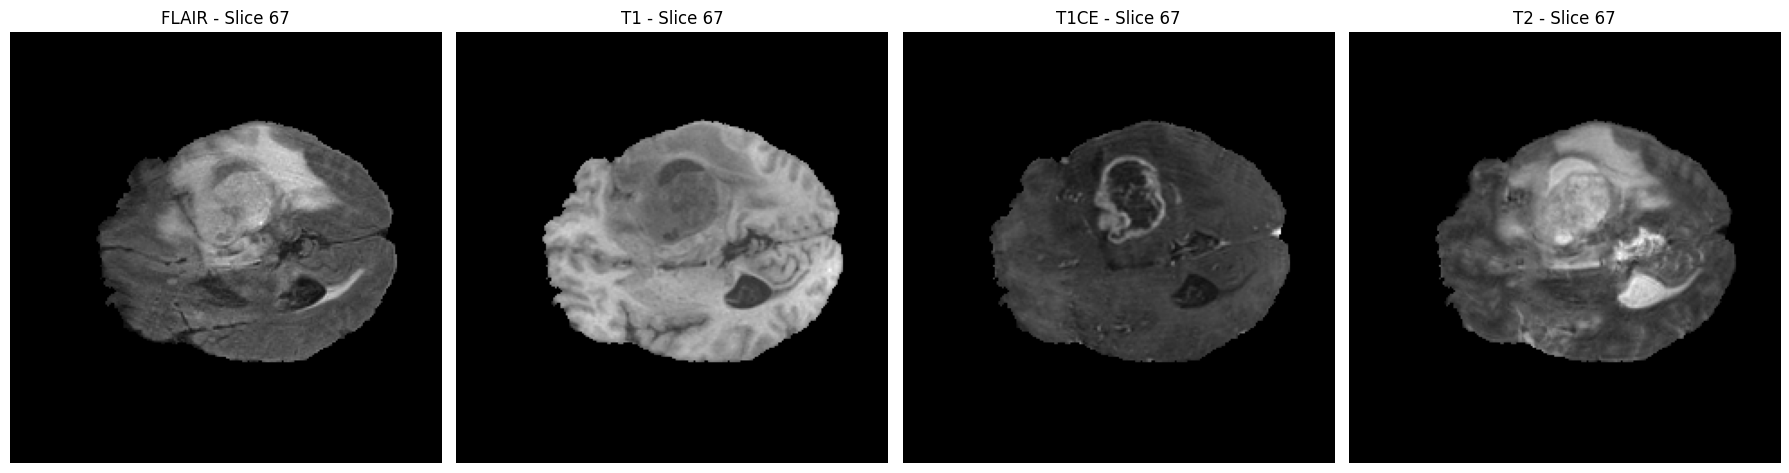

In [22]:
sample_patient = "BraTS20_Training_001"
mask_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_seg.nii")
mask_data = nib.load(mask_path).get_fdata()

slice_areas = [np.sum(mask_data[:, :, i] > 0) for i in range(mask_data.shape[2])]
best_slice_idx = np.argmax(slice_areas)

print(f"Top tumor intensity found in Slice: {best_slice_idx}")

modalities = ['flair', 't1', 't1ce', 't2']
plt.figure(figsize=(18, 5))

for i, mod in enumerate(modalities):
    mod_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_{mod}.nii")
    mod_data = nib.load(mod_path).get_fdata()

    plt.subplot(1, 4, i + 1)
    plt.imshow(mod_data[:, :, best_slice_idx], cmap="gray")
    plt.title(f"{mod.upper()} - Slice {best_slice_idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Visualizing Patient: BraTS20_Training_001 | Best Tumor Slice: 67


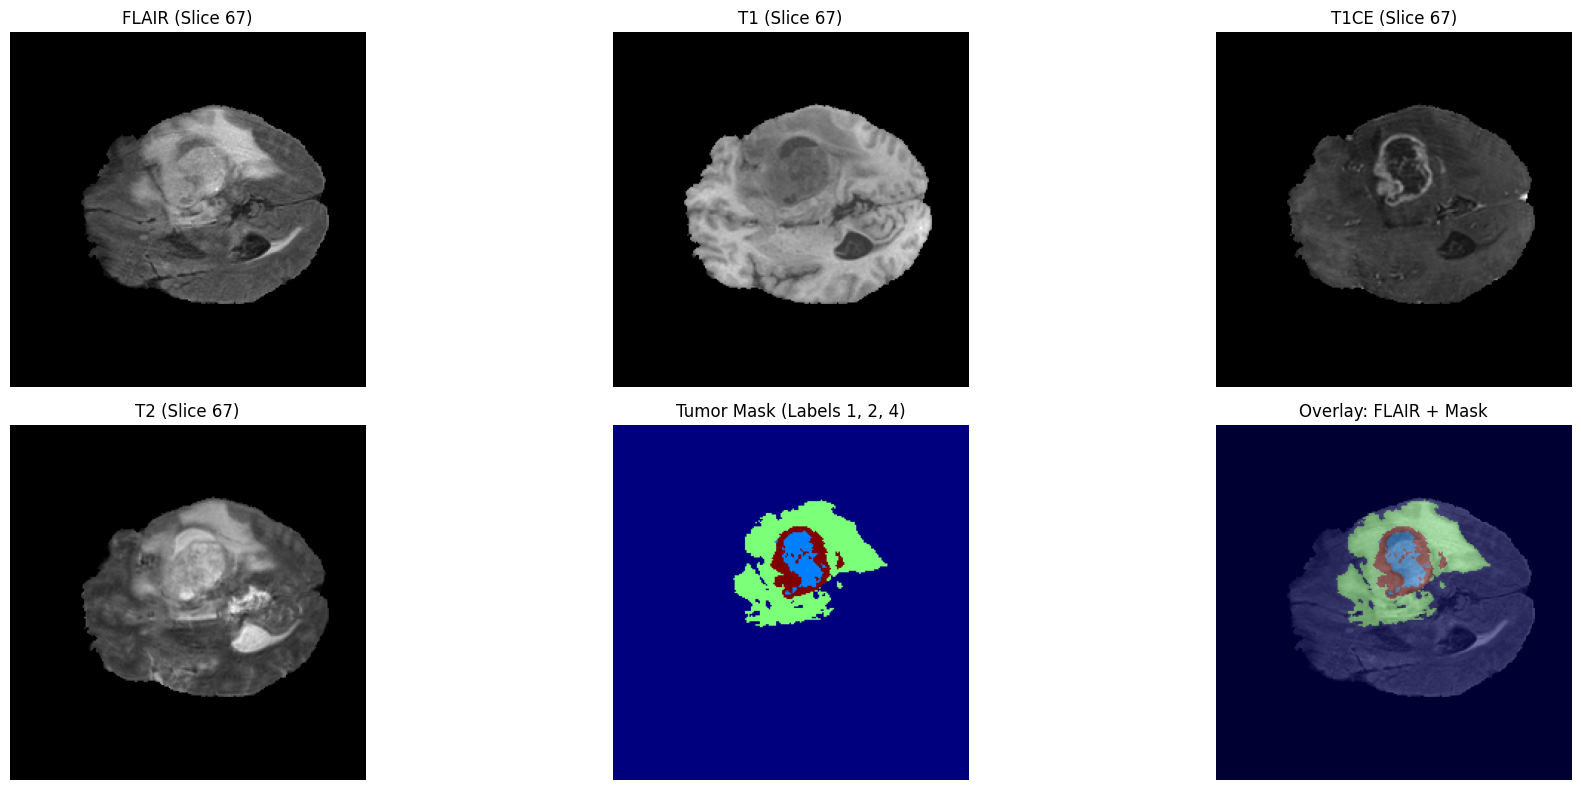

In [24]:
print(f"Visualizing Patient: {sample_patient} | Best Tumor Slice: {best_slice_idx}")

modalities = ['flair', 't1', 't1ce', 't2']
plt.figure(figsize=(20, 8))

for i, mod in enumerate(modalities):
    mod_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_{mod}.nii")
    mod_data = nib.load(mod_path).get_fdata()

    plt.subplot(2, 3, i + 1)
    plt.imshow(mod_data[:, :, best_slice_idx], cmap="gray")
    plt.title(f"{mod.upper()} (Slice {best_slice_idx})")
    plt.axis("off")

mask_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_seg.nii")
mask_data = nib.load(mask_path).get_fdata()

plt.subplot(2, 3, 5)
plt.imshow(mask_data[:, :, best_slice_idx], cmap="jet")
plt.title("Tumor Mask (Labels 1, 2, 4)")
plt.axis("off")

flair_path = os.path.join(TRAIN_DATA_PATH, sample_patient, f"{sample_patient}_flair.nii")
flair_data = nib.load(flair_path).get_fdata()

plt.subplot(2, 3, 6)
plt.imshow(flair_data[:, :, best_slice_idx], cmap="gray")
plt.imshow(mask_data[:, :, best_slice_idx], cmap="jet", alpha=0.4)
plt.title("Overlay: FLAIR + Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Distribution of Tumor Sizes (Pixel Count)

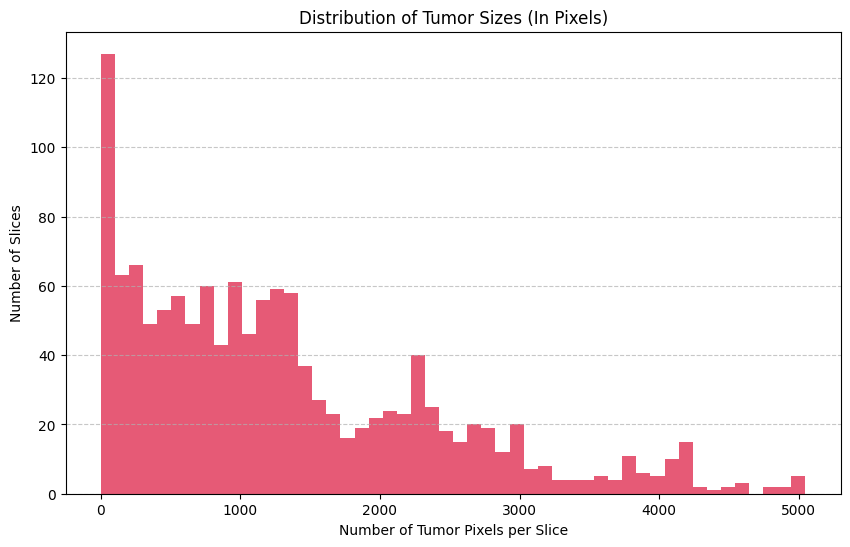

Average tumor size per slice: 1305.37 pixels


In [23]:
tumor_pixel_counts = []

for patient in patient_folders[:sample_size]:
    mask_path = os.path.join(TRAIN_DATA_PATH, patient, f"{patient}_seg.nii")
    mask_data = nib.load(mask_path).get_fdata()

    for i in range(mask_data.shape[2]):
        count = np.sum(mask_data[:, :, i] > 0)
        if count > 0:
            tumor_pixel_counts.append(count)

plt.figure(figsize=(10, 6))
plt.hist(tumor_pixel_counts, bins=50, color='crimson', alpha=0.7)
plt.title("Distribution of Tumor Sizes (In Pixels)")
plt.xlabel("Number of Tumor Pixels per Slice")
plt.ylabel("Number of Slices")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tumor size per slice: {np.mean(tumor_pixel_counts):.2f} pixels")